In [1]:
import os
from llm import get_client, summarize_repo
from collections import defaultdict
from dataclasses import dataclass
from typing import Iterable
import fnmatch
from pathlib import Path
from extractor import build_repo_profile
from typing import List
import json

In [2]:
os.environ['NEBIUS_API_KEY'] = "v1.CmQKHHN0YXRpY2tleS1lMDBubmp3bm52ZWdmOW1xcjESIXNlcnZpY2VhY2NvdW50LWUwMHhycnl0eWU5NTlhMDZqZTIMCIm28swGENCekq0COgwIiLmKmAcQgI-OxwJAAloDZTAw.AAAAAAAAAAEDvlmf4zvsU99xk2-GEj7IdhuDXTD_ImLWbB4yDuBWznxcvkyhoxr6rhO9bbOOk0Wbpjh_Ire5q-j68lv22B8P"

In [3]:
client = get_client()
# github_url = 'https://github.com/zhozheka/hidden_random'
# # github_url = 'https://github.com/zhozheka/hidden_random'

# with tempfile.TemporaryDirectory() as tmp_repo_dir:
#     tmp_repo_dir = '/tmp/4'
#     # download_repo(github_url, tmp_repo_dir)
#     repo_profile = extract_repo_profile(tmp_repo_dir)


In [4]:
# repo_summary = summarize_repo(client, repo_profile, model='meta-llama/Llama-3.3-70B-Instruct-fast')
# result = repo_summary.model_dump_json()

In [5]:
build_repo_profile(Path(tmp_repo_dir), Path('.'), max_depth=3, write_chunks=True)

NameError: name 'tmp_repo_dir' is not defined

In [7]:
DEFAULT_IGNORE_DIRS = {
    ".git", ".hg", ".svn",
    "node_modules", "bower_components",
    "dist", "build", "out", ".next", ".nuxt",
    "target", "bin", "obj",
    ".venv", "venv", "__pycache__", ".tox",
    "coverage", ".pytest_cache",
    ".idea", ".vscode",
    "vendor",
}


def get_tree_of_dirs(repo_path: str, max_depth: int = None) -> list[str]:
    """
    Return a sorted list of directory paths within the repository.

    - Paths are returned relative to repo_path using forward slashes.
    - Common generated/vendor directories are skipped.
    - Includes top-level directories (e.g., "src") and nested directories (e.g., "src/api").
    """
    root = Path(repo_path).resolve()
    if not root.exists() or not root.is_dir():
        raise ValueError(f"repo_path is not a directory: {repo_path}")

    dirs = set()
    for dirpath, dirnames, _filenames in os.walk(root):
        # prune ignored directories in-place
        dirnames[:] = [d for d in dirnames if d not in DEFAULT_IGNORE_DIRS]
        current = Path(dirpath)
        for d in dirnames:
            p = current / d
            try:
                rel = p.relative_to(root).as_posix()
            except Exception:
                continue
            # avoid adding "." (shouldn't happen) and keep non-empty
            if not rel or rel == ".":
                continue
            
            if max_depth is not None and len(Path(rel).parts) > max_depth:
                continue

            dirs.add(rel)

    return sorted(dirs)

In [8]:
# Reuse your existing ignore sets if you have them
LOCKFILE_NAMES = {
    "yarn.lock", "package-lock.json", " pnpm-lock.yaml",
    "composer.lock", "Gemfile.lock", "Cargo.lock", "go.sum",
}

BINARY_EXTS = {
    ".png", ".jpg", ".jpeg", ".gif", ".bmp", ".ico", ".pdf",
    ".zip", ".tar", ".gz", ".bz2", ".7z",
    ".exe", ".dll", ".so", ".dylib",
    ".mp4", ".mov", ".mp3", ".wav",
}

def _sniff_is_binary(p: Path, sniff_bytes: int = 2048) -> bool:
    try:
        with p.open("rb") as f:
            chunk = f.read(sniff_bytes)
        return b"\x00" in chunk
    except Exception:
        return True


In [ ]:
MAX_PRIORITY = 1000
BASE_PRIORITY = 100
DECAY_PER_DEPTH = 10
MAX_CHARS_PER_FILE = 10_000

KEY_FILE_RULES = [
    # 1000: Repo intent / architecture
    (1000, [
        "README", "README.*",
        "docs/index.md", "docs/README.md", "docs/overview.md", "docs/architecture.md",
        "docs/adr/*.md", "docs/adr/**/*.md",
        "ARCHITECTURE.*", "DESIGN.*",
        
    ]),
    # 950: Build + dependency manifests (tell you "what it is" quickly)
    (950, [
        # Node
        "package.json", "pnpm-workspace.yaml", "lerna.json", "nx.json", "turbo.json", "rush.json",
        "tsconfig.json", "tsconfig.*.json",
        # Python
        "pyproject.toml", "requirements.txt", "requirements-*.txt", "requirements/*.txt",
        "Pipfile", "setup.py", "setup.cfg",
        # JVM
        "pom.xml", "build.gradle", "build.gradle.kts", "settings.gradle", "settings.gradle.kts",
        # Other ecosystems
        "go.mod", "Cargo.toml",
        "*.sln", "*.csproj", "Directory.Packages.props", "NuGet.config",
        "composer.json", "Gemfile",
    ]),
    # 920: Common entrypoints (tell you "what it does" quickly, but can be noisy and less standardized than manifests)
    (920, [
        # Common root entrypoints
        "main.py", "app.py", "server.py", "__main__.py", "manage.py",
        "main.ts", "index.ts", "server.ts", "app.ts",
        "main.js", "index.js", "server.js", "app.js",

        # CLIs
        "cli.py", "src/cli.py",
        "bin/*", "scripts/*",
    ]),
    # 900: Public interfaces / contracts
    (900, [
        "*openapi*.yml", "*openapi*.yaml", "*openapi*.json",
        "*swagger*.yml", "*swagger*.yaml", "*swagger*.json",
        "schema.graphql", "*.graphql",
        "*.proto",
        "*asyncapi*.yml", "*asyncapi*.yaml", "*asyncapi*.json",
        "*.schema.json",
    ]),
    
    # 800: CI/CD + release automation (how it builds/tests/deploys)
    (800, [
        ".github/workflows/*.yml", ".github/workflows/*.yaml",
        ".gitlab-ci.yml", "azure-pipelines.yml", ".circleci/config.yml",
        ".github/dependabot.yml", "renovate.json",
        ".pre-commit-config.yaml",
    ]),
    # 750: Deployment/infra/runtime packaging
    (750, [
        "Dockerfile", "docker-compose.yml", "docker-compose.*.yml",
        "k8s/*.yml", "k8s/*.yaml", "manifests/*.yml", "manifests/*.yaml",
        "charts/Chart.yaml", "charts/*/Chart.yaml", "charts/values.yaml", "charts/*/values.yaml",
        "*.tf", "terragrunt.hcl", "serverless.yml", "Pulumi.*",
    ]),
    # 700: DB + migrations (what data it owns)
    (700, [
        "migrations/*", "migrations/**/*",
        "prisma/schema.prisma",
        "alembic.ini",
    ]),
    # 650: Policies / contribution (less critical for "what it does", but still useful)
    (650, [
        "CHANGELOG.*", "HISTORY.*", "RELEASE_NOTES.*",
        "LICENSE", "LICENSE.*", "COPYING*",
        "CONTRIBUTING.*", "SECURITY.*", "CODE_OF_CONDUCT.*", "CODEOWNERS",
        ".gitignore", ".editorconfig",
    ]),
    # 600: Env templates (sanitize before sending anywhere)
    (600, [
        ".env.example", ".env.template",
    ]),
]

# Lockfiles are useful for tech signals but usually too big/noisy for LLM context.

@dataclass(frozen=True)
class KeyFile:
    relpath: str
    abspath: Path
    priority: int


def _match_any(relpath: str, patterns: Iterable[str]) -> bool:
    rel = relpath.lower()
    base = Path(relpath).name.lower()
    for pat in patterns:
        p = pat.lower()
        if fnmatch.fnmatch(rel, p) or fnmatch.fnmatch(base, p):
            return True
    return False


def find_key_files(repo_path: str, decay_readme: bool = True, max_readmes: int = 20) -> list[KeyFile]:
    n_readmes = 0
    root = Path(repo_path).resolve()
    if not root.exists() or not root.is_dir():
        raise ValueError(f"repo_path is not a directory: {repo_path}")

    files: List[KeyFile] = []
    
    for dirpath, dirnames, filenames in os.walk(root):
        if Path(dirpath).name in DEFAULT_IGNORE_DIRS:
            continue
        depth = len(Path(dirpath).relative_to(root).parts)

        for fn in filenames:
            if fn in LOCKFILE_NAMES:
                continue

            p = Path(dirpath) / fn

            # skip binary files
            if p.suffix.lower() in BINARY_EXTS or _sniff_is_binary(p):
                continue

            if fn == "readme" or fn.startswith("readme.") and decay_readme:
                n_readmes += 1
                if n_readmes > max_readmes:
                    priority = BASE_PRIORITY - depth * DECAY_PER_DEPTH
                else:
                    priority = MAX_PRIORITY - depth * 25 # decay readme priority by depth
                files.append(KeyFile(relpath=str(Path(dirpath).relative_to(root) / fn), abspath=Path(dirpath) / fn, priority=priority))
                continue


            p = Path(dirpath) / fn
            try:
                rel = p.relative_to(root).as_posix()
            except Exception:
                continue
            
            priority = BASE_PRIORITY
            for priority_, patterns in KEY_FILE_RULES:
                if _match_any(rel, patterns):
                    priority = priority_ - depth * DECAY_PER_DEPTH 
                    break
            
            files.append(KeyFile(relpath=rel, abspath=p, priority=priority))
    return sorted(files, key=lambda k: (-k.priority, k.relpath.lower()))


In [28]:
def _count_loc(p: Path) -> int:
    # Count non-empty lines; tolerate mixed encodings
    try:
        with p.open("r", encoding="utf-8", errors="ignore") as f:
            return sum(1 for line in f if line.strip())
    except Exception:
        return 0

def get_extension_counter(files: list[KeyFile], prune: bool = True) -> dict[str, dict[str, int]]:
    extension_counter = defaultdict(lambda: {"files": 0, "loc": 0})

    for kf in files:
        p = kf.abspath

        ext = p.suffix  # keeps leading dot; empty string for no suffix
        extension_counter[ext]["files"] += 1
        extension_counter[ext]["loc"] += _count_loc(p)
    if prune:
        # Remove extensions that only appear once and have very few lines of code (likely not significant for repo profile)
        extension_counter = dict(
            (ext, data) for ext, data in extension_counter.items() 
            if data["files"] > 5 and data["loc"] > 0
        )
    return extension_counter

In [29]:
repo_path= '/Users/evgeny-home/repos/jdk'

files = find_key_files(repo_path)
extension_counter = get_extension_counter(files)

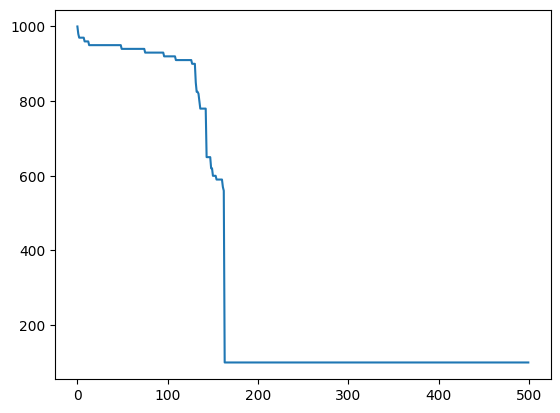

In [30]:
import matplotlib.pyplot as plt
plt.plot([f.priority for f in files][:500])

In [31]:
repo_profile = {
    'repo_name': Path(repo_path).name,
    'num_files': len(files),
    'extensions': extension_counter,
}

In [34]:
from llm import MAX_CHARS, MODEL

In [35]:
# pack files 
files_budget = MAX_CHARS - len(json.dumps(repo_profile))
key_files_content = {}
while files_budget > 0 and files:
    kf = files.pop(0)
    try:
        content = kf.abspath.read_text(encoding="utf-8", errors="ignore")[:MAX_CHARS_PER_FILE]
    except Exception:
        continue
    
    new_file_budget = len(content) + len(kf.relpath) + 100 # add some overhead for formatting
    if new_file_budget > files_budget:
        break
    key_files_content[kf.relpath] = content
    files_budget -= new_file_budget

repo_profile['key_files'] = key_files_content

In [36]:
summarize_repo(client, repo_profile, model=MODEL).model_dump()

{'summary': 'The JDK repository is a massive collection of Java development kit code, comprising over 69,000 files across various extensions.',
 'technologies': ['Java',
  'C',
  'C++',
  'XML',
  'HTML',
  'CSS',
  'JavaScript',
  'Makefile',
  'CMake',
  'Shell Script'],
 'structure': 'The repository has a complex structure with multiple directories and subdirectories, containing a mix of source code, documentation, and configuration files.'}

In [ ]:
repo_dir = '/Users/evgeny-home/repos/pytorch'

In [ ]:
tree_of_files_depth_2 = get_all_files(repo_path=repo_dir, max_depth=2)
tree_of_files_depth_3 = get_all_files(repo_path=repo_dir, max_depth=3)
tree_of_dirs = get_tree_of_dirs(repo_path=repo_dir, max_depth=5)


# key_files = load_key_files(key_files_list)

extension_counter = get_extension_counter(repo_path=repo_dir)

In [ ]:
files.pop(0)

In [ ]:
key_files_list = find_key_files(repo_path=repo_dir, max_results=10000, include_lockfiles=False)

In [ ]:
for path in all_files:
    if path.name == 'main.py':
        print(path)

In [ ]:
repo_profile = {
    'tree_of_dirs': tree_of_dirs,
    'tree_of_files_depth_2': [p.as_posix() for p in tree_of_files_depth_2],
    # 'tree_of_files_depth_3': [p.as_posix() for p in tree_of_files_depth_3],
    'key_files': key_files,
    'extension_counter': extension_counter_f,
}

In [ ]:
for k, v in repo_profile.items():
    print(f"{k}: {len(json.dumps(v))}")

print(f"Total chars: {len(json.dumps(repo_profile))}")

tree_of_dirs: 21
tree_of_files_depth_2: 1133
key_files: 4896
extension_counter: 131
Total chars: 6264


In [ ]:
summarize_repo(client, repo_profile, model='meta-llama/Meta-Llama-3.1-8B-Instruct').model_dump()

{'summary': 'A project implementing a paper on randomly weighted neural networks. The codebase includes various neural network architectures, datasets, and training scripts.',
 'technologies': ['Python',
  'TensorFlow',
  'PyTorch',
  'Numpy',
  'Scikit-learn',
  'OpenCV',
  'Pandas',
  'Scipy',
  'Matplotlib',
  'Seaborn'],
 'structure': 'The project consists of a models directory containing neural network architectures, a scripts directory with training scripts, and various utility files. The file structure is well-organized, with clear directory trees and descriptive file names.'}

In [ ]:
key_files_list = find_key_files(repo_path=repo_dir, max_results=10000, include_lockfiles=False)
len(key_files_list)

347